# Overview

In this notebook, we will build a machine learning clasification model using k-Nearest Neighbors algorithm on diabetes dataset to predict whether the patients have diabetes or not. Let's look at the notebook execution.


In [1]:
# import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

1. **Preparing and loading the data**

In [2]:
#Loading the dataset
diabetes_data = pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')

#Print the first 5 rows of the dataframe.
diabetes_data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Also I used diabetes_data.sample() because .sample() picksa up rows randomly that's why we get non bised view. Now we can see data types and brief statistical summary.

1.  **Basic EDA and Statistical Analysis**

In [3]:
diabetes_data.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
598,1,173,74,0,0,36.8,0.088,38,1
196,1,105,58,0,0,24.3,0.187,21,0
528,0,117,66,31,188,30.8,0.493,22,0
603,7,150,78,29,126,35.2,0.692,54,1
266,0,138,0,0,0,36.3,0.933,25,1
324,2,112,75,32,0,35.7,0.148,21,0
513,2,91,62,0,0,27.3,0.525,22,0
747,1,81,74,41,57,46.3,1.096,32,0
456,1,135,54,0,0,26.7,0.687,62,0
545,8,186,90,35,225,34.5,0.423,37,1


In [4]:
# Getting dataframe columns names
df_name=diabetes_data.columns

In [5]:
diabetes_data.describe() # Returns description of the data in the DataFrame

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# to observe the shape of the dataframe.
diabetes_data.shape

(768, 9)

In [7]:
# data attribute information
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
diabetes_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [9]:
#Just printing columns name
diabetes_data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [10]:
# to check count of zero entries for each of this column
colsToModify = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',]
for col in colsToModify:
  print(col + " - ")
  print(diabetes_data[diabetes_data[col] == 0][col].value_counts())

Pregnancies - 
0    111
Name: Pregnancies, dtype: int64
Glucose - 
0    5
Name: Glucose, dtype: int64
BloodPressure - 
0    35
Name: BloodPressure, dtype: int64
SkinThickness - 
0    227
Name: SkinThickness, dtype: int64
Insulin - 
0    374
Name: Insulin, dtype: int64
BMI - 
0.0    11
Name: BMI, dtype: int64


In [11]:
# to Count zero entries
print("Count of zero entries") 
colsToModify = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',]
val = []
for col in colsToModify:
  val.append(len(diabetes_data[diabetes_data[col] == 0]))
zeroCount = pd.DataFrame(val, index = colsToModify, columns = ['zeroCount'])
zeroCount

Count of zero entries


,zeroCount
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


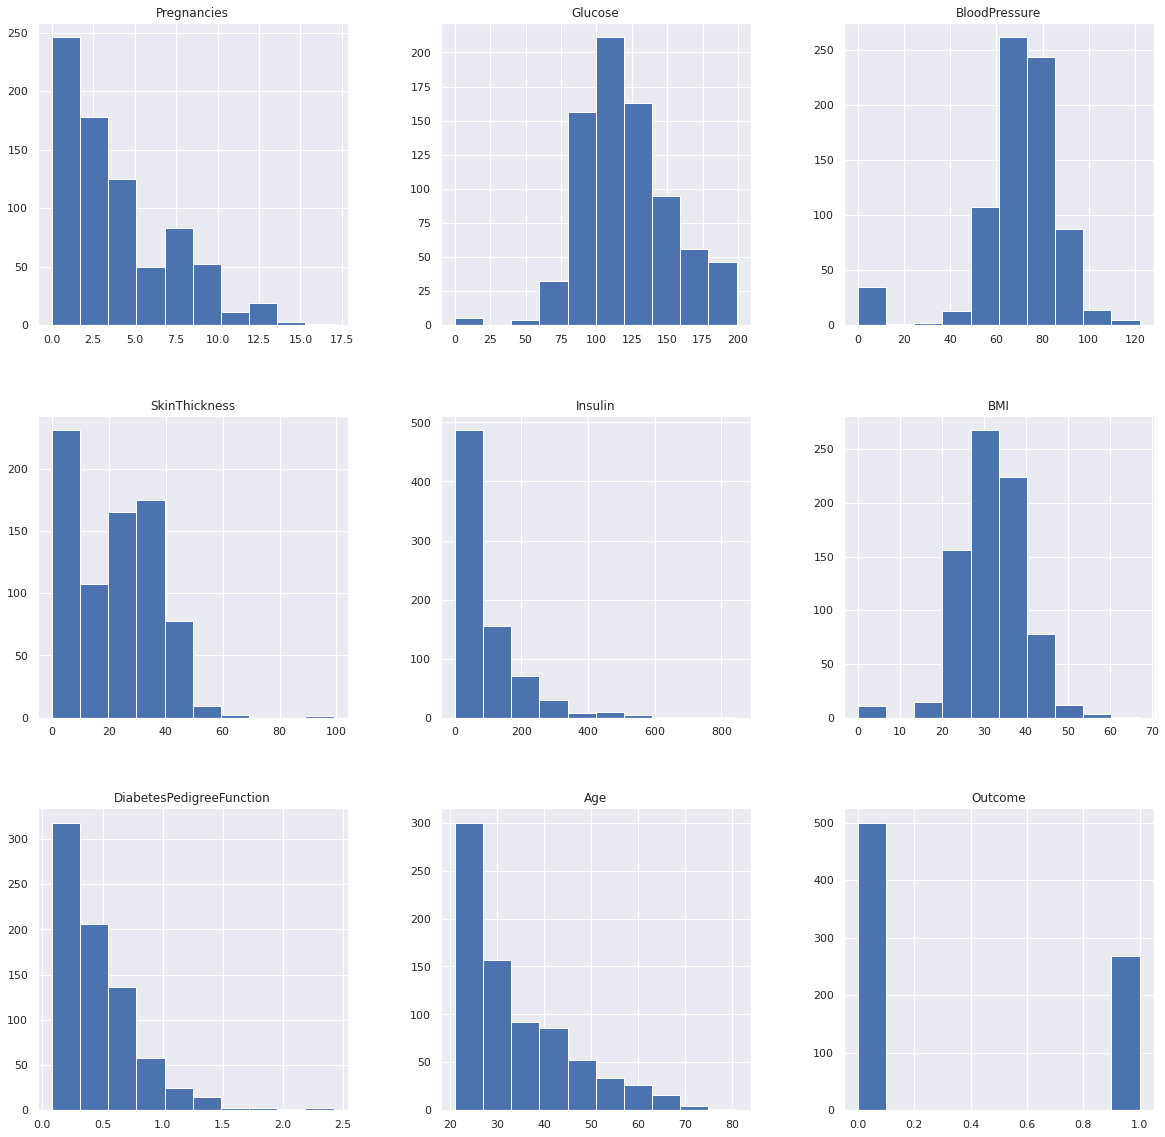

In [12]:
p = diabetes_data.hist(figsize = (20,20))

In [13]:
# Replacing zero value with respective mean vale
for col in colsToModify:
    diabetes_data[col] = diabetes_data[col].replace(0,np.NaN)
    mean = int(diabetes_data[col].mean(skipna = True))
    diabetes_data[col] = diabetes_data[col].replace(np.NaN, mean)
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,155.0,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,155.0,26.6,0.351,31,0
2,8.0,183.0,64.0,29.0,155.0,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,4.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [14]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.000000,768.000000
mean,4.423177,121.682292,72.386719,29.108073,155.28125,32.450911,0.471876,33.240885,0.348958
std,2.980481,30.435999,12.096642,8.791221,85.02155,6.875366,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.00000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,25.000000,121.50000,27.500000,0.243750,24.000000,0.000000
50%,4.000000,117.000000,72.000000,29.000000,155.00000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.00000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.00000,67.100000,2.420000,81.000000,1.000000


In [15]:
diabetes_data.duplicated().sum()

0

In [16]:
diabetes_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

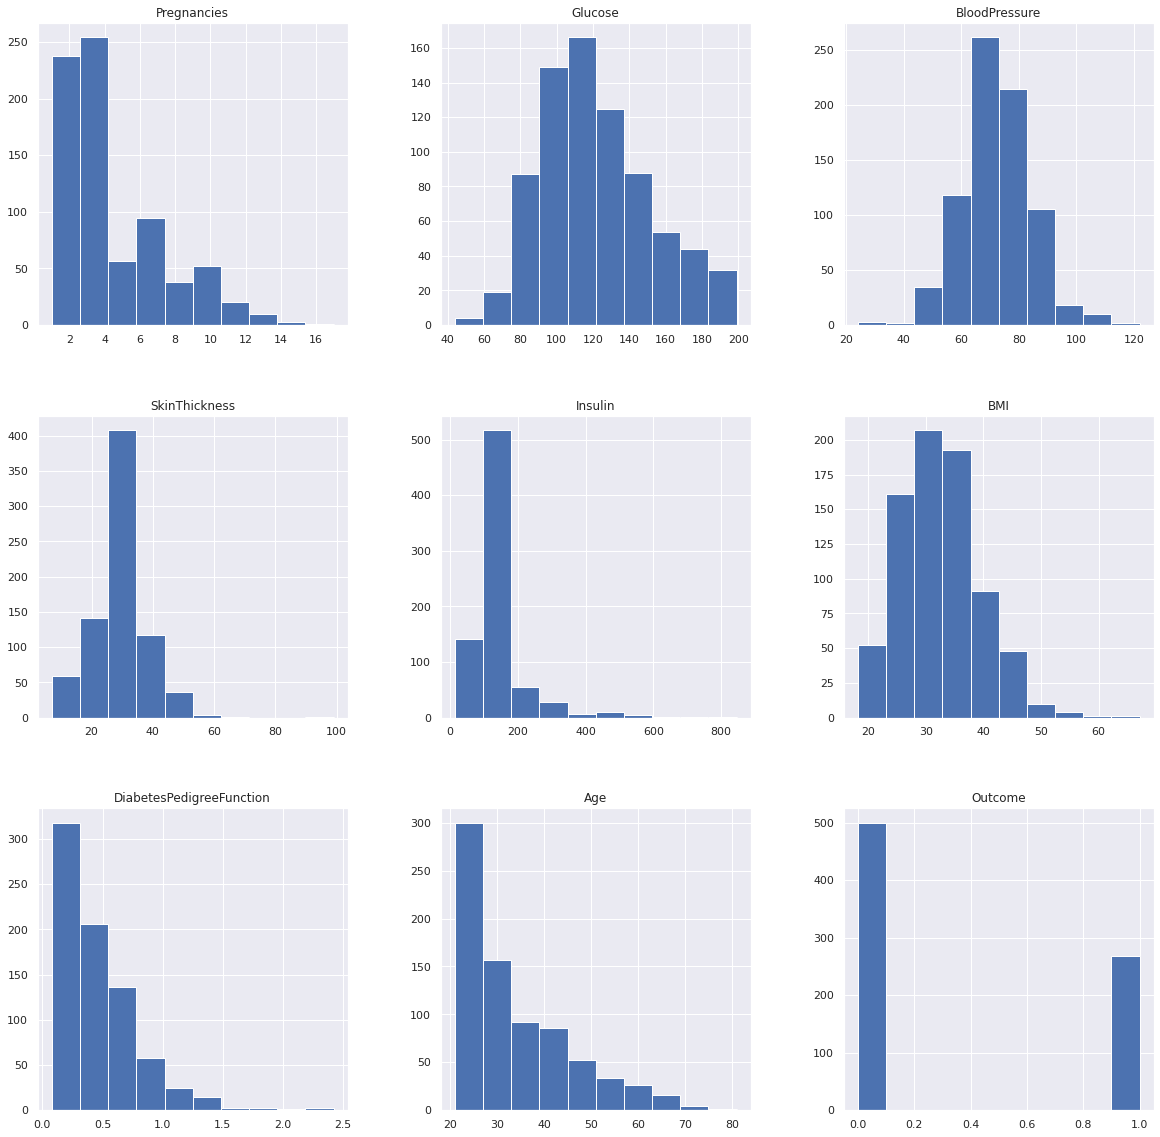

In [17]:
p = diabetes_data.hist(figsize = (20,20))

3. **Data Visuliation**

array([<AxesSubplot:ylabel='Outcome'>], dtype=object)

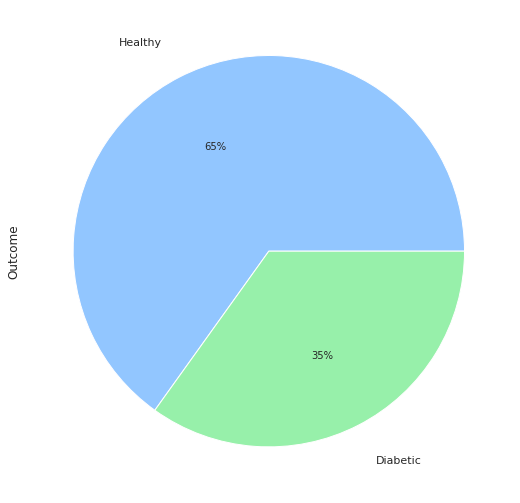

In [18]:
import matplotlib.style as style
style.available

style.use('seaborn-pastel')
labels = ["Healthy", "Diabetic"]
diabetes_data['Outcome'].value_counts().plot(kind='pie',labels=labels, subplots=True,autopct='%1.0f%%', labeldistance=1.2, figsize=(9,9))

<AxesSubplot:>

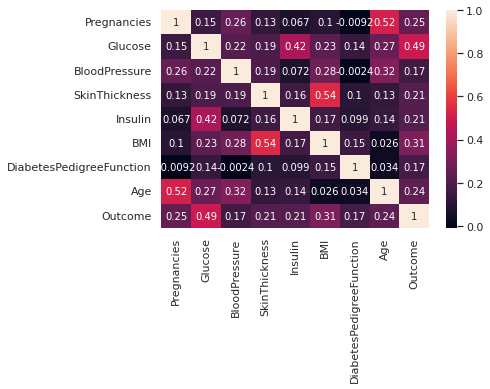

In [19]:
corr=diabetes_data.corr() 
sns.heatmap(corr, annot=True) # an array of the same shape as data which is used to annotate the heatmap

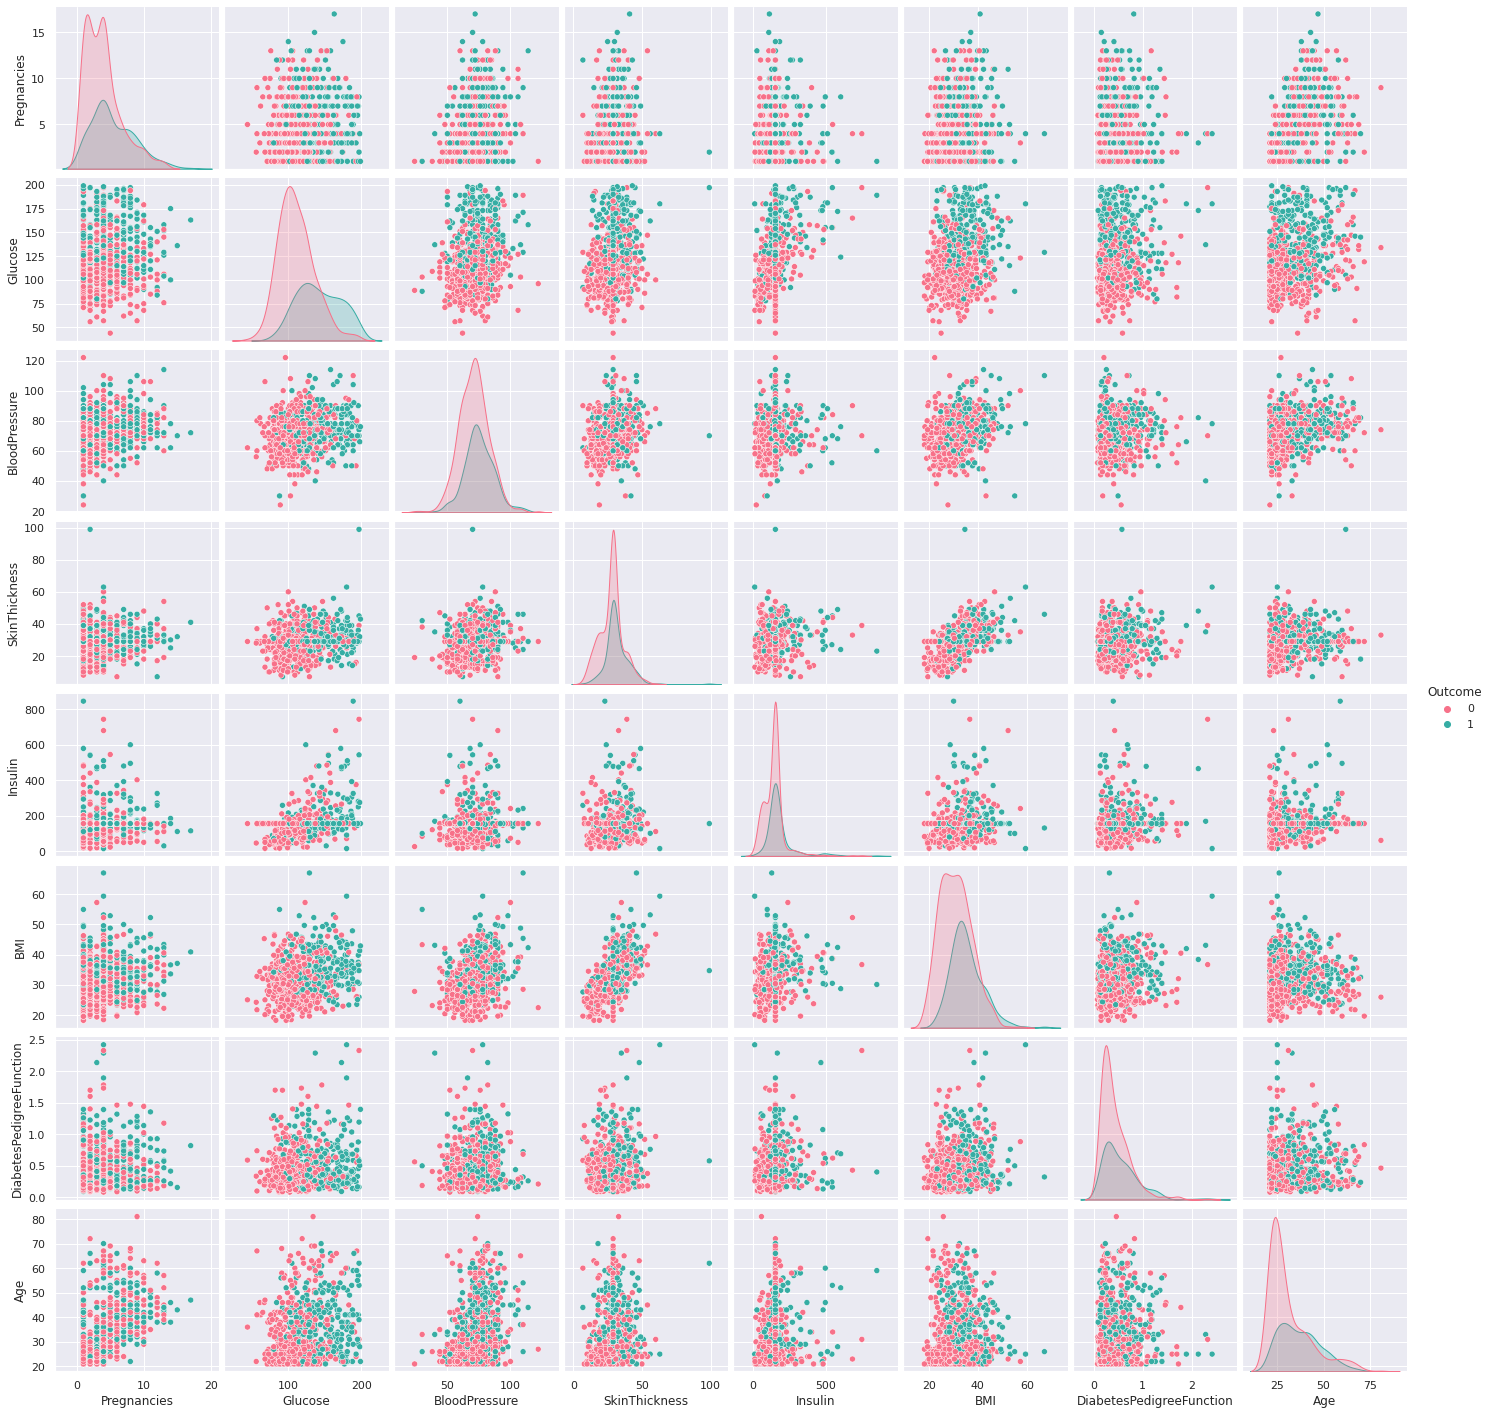

In [20]:
g = sns.pairplot(diabetes_data, hue="Outcome", palette="husl")

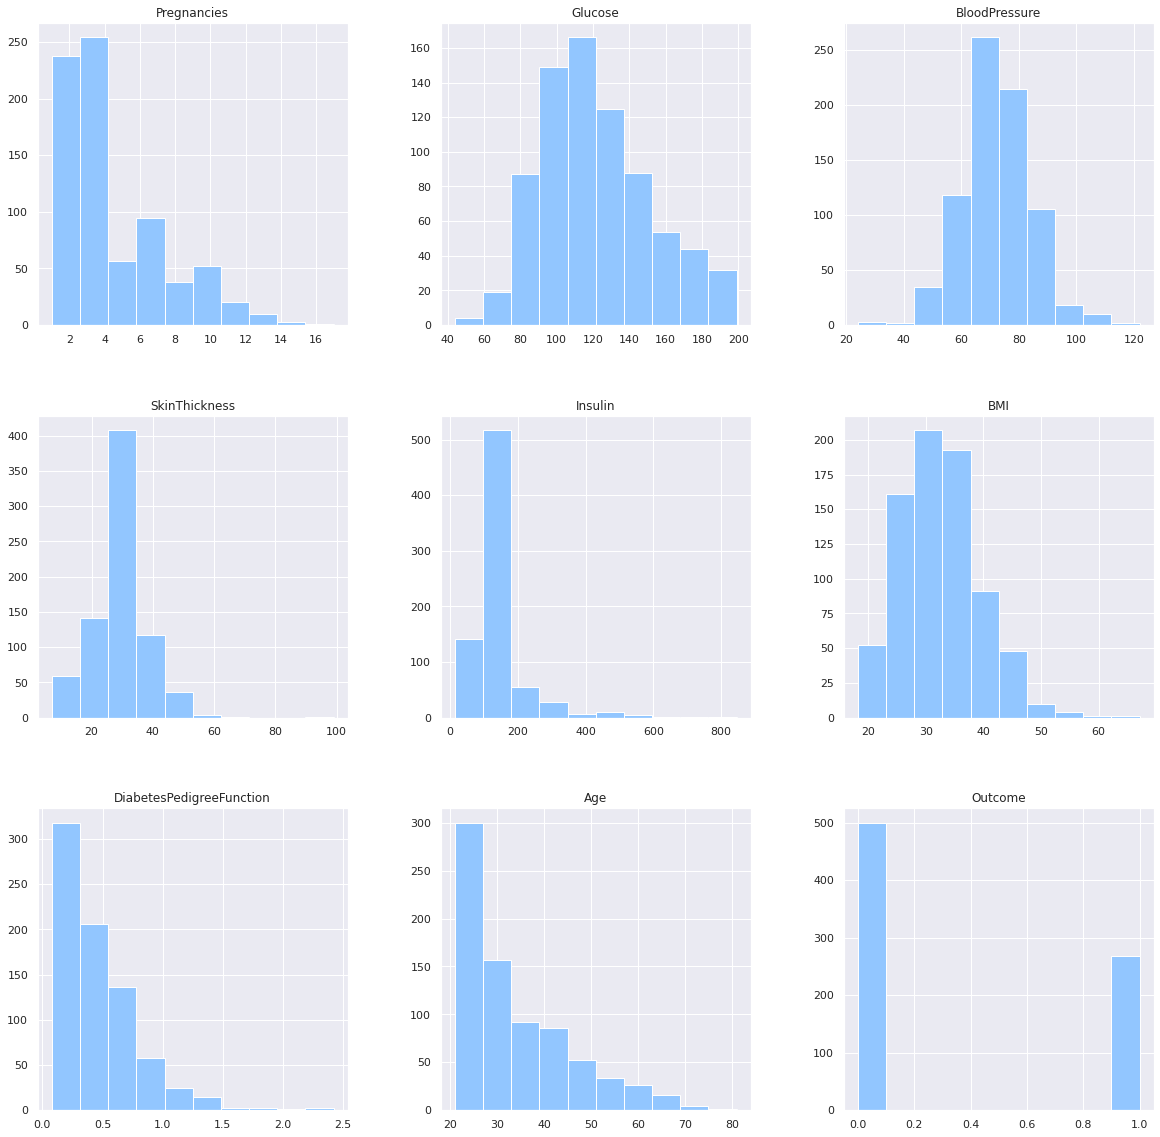

In [21]:
p = diabetes_data.hist(figsize = (20,20))

Samples of diabetic people:  268
Samples of healthy people:  500


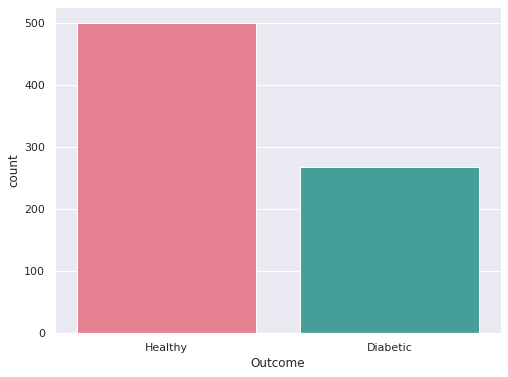

In [22]:
from matplotlib.pyplot import figure, show

figure(figsize=(8,6))
ax = sns.countplot(x=diabetes_data['Outcome'], data=diabetes_data,palette="husl")
ax.set_xticklabels(["Healthy","Diabetic"])
healthy, diabetics = diabetes_data['Outcome'].value_counts().values
print("Samples of diabetic people: ", diabetics)
print("Samples of healthy people: ", healthy)

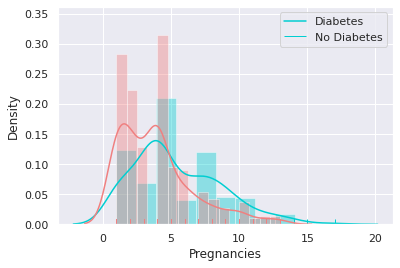

In [23]:
plt.figure()
ax = sns.distplot(diabetes_data['Pregnancies'][diabetes_data.Outcome == 1], color ="darkturquoise", rug = True)
sns.distplot(diabetes_data['Pregnancies'][diabetes_data.Outcome == 0], color ="lightcoral",rug = True)
plt.legend(['Diabetes', 'No Diabetes'])

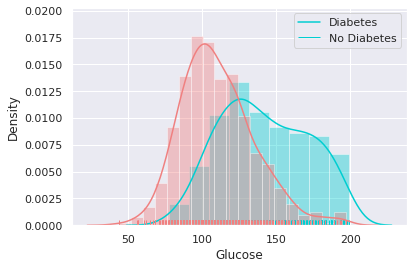

In [24]:
plt.figure()
ax = sns.distplot(diabetes_data['Glucose'][diabetes_data.Outcome == 1], color ="darkturquoise", rug = True)
sns.distplot(diabetes_data['Glucose'][diabetes_data.Outcome == 0], color ="lightcoral", rug = True)
plt.legend(['Diabetes', 'No Diabetes'])

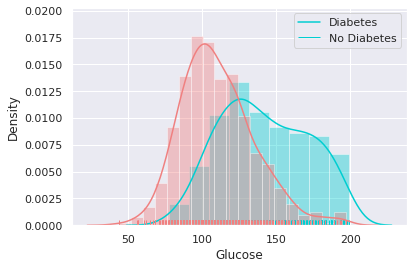

In [25]:
plt.figure()
ax = sns.distplot(diabetes_data['Glucose'][diabetes_data.Outcome == 1], color ="darkturquoise", rug = True)
sns.distplot(diabetes_data['Glucose'][diabetes_data.Outcome == 0], color ="lightcoral", rug = True)
plt.legend(['Diabetes', 'No Diabetes'])

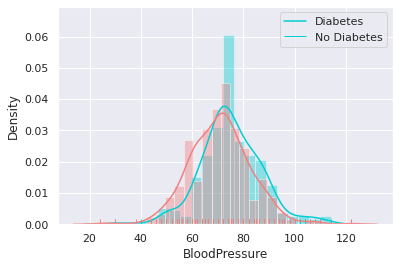

In [26]:
plt.figure()
ax = sns.distplot(diabetes_data['BloodPressure'][diabetes_data.Outcome == 1], color ="darkturquoise", rug=True)
sns.distplot(diabetes_data['BloodPressure'][diabetes_data.Outcome == 0], color ="lightcoral", rug=True)
plt.legend(['Diabetes', 'No Diabetes'])

**4. Outlier Detection**

from the visulization above 

1. **Suplitting The Data**

In [27]:
from sklearn.model_selection import train_test_split
X =diabetes_data.iloc[:,0:8]
y =diabetes_data.iloc[:,8]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=21, stratify = y)

In [28]:
#feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=21, p=2, metric='euclidean')

In [30]:
classifier.fit(X_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=21)

In [31]:
y_pred =  classifier.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [32]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test,y_pred)
cm

array([[90, 10],
       [35, 19]])

In [33]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.7077922077922078


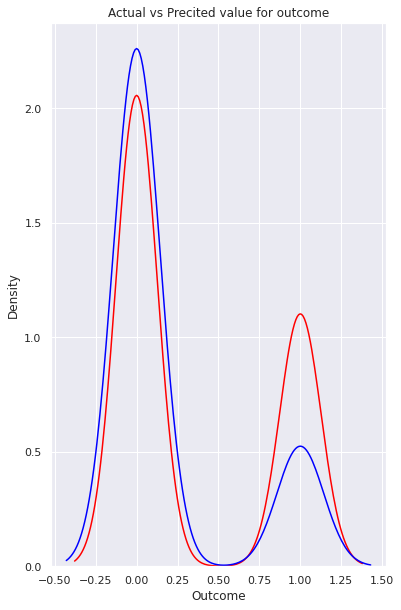

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 10))

ax = sns.distplot(diabetes_data['Outcome'], hist=False, color="red", label="Actual Value")
sns.distplot(y_pred, hist=False, color="blue", label="Predicted Values",  ax=ax)

plt.title('Actual vs Precited value for outcome')
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
X =diabetes_data.iloc[:,0:8]
y =diabetes_data.iloc[:,8]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=21, stratify = y)

In [36]:
#feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
# To convert the scaled training data into a dataframe
feat = pd.DataFrame(X_train, columns=diabetes_data.columns[:-1])
feat.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.821385,1.245954,-1.551563,0.340581,0.196492,-0.286803,0.361539,0.443927
1,-0.523496,0.264368,-0.732353,-0.003173,-0.031529,-1.342389,-0.464985,-0.995560
2,1.157606,1.474991,2.708331,1.944764,0.834950,0.725988,-0.914445,0.782630
3,-0.187276,0.787880,0.742226,-0.003173,-0.031529,1.139663,3.960236,0.867306
4,-0.187276,1.409551,1.397595,0.455165,5.954021,2.822894,-0.124119,-0.910885


In [38]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=3) 
clf.fit(X_train,y_train)  
print(clf.score(X_test,y_test))

0.7337662337662337


In [39]:
# Code to collect accuracy as list for several k values
from sklearn.model_selection import cross_val_score
accuracy_rate = []

for i in range(1,25):
  knn = KNeighborsClassifier(n_neighbors=i)
  score=cross_val_score(knn, feat ,y_train, cv=8)
  accuracy_rate.append(score.mean())

Text(0, 0.5, 'Accuracy Rate')

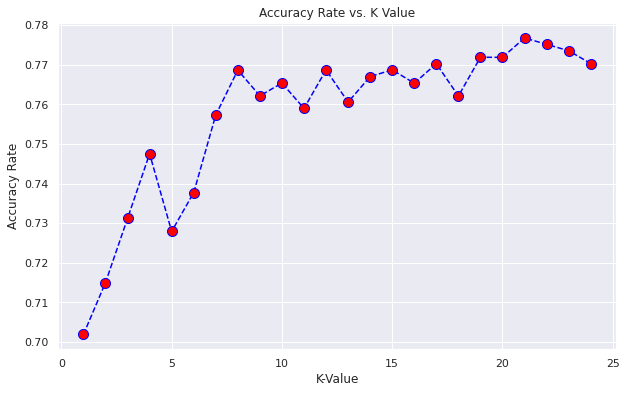

In [40]:
#Code to plot accuracy against that k
plt.figure(figsize=(10,6))

plt.plot(range(1,25),accuracy_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Accuracy Rate vs. K Value')
plt.xlabel('K-Value')
plt.ylabel('Accuracy Rate')

In [41]:
#Like accuracy we can have plot for error rate also.
error_rate = []
for i in range(1,25):
  knn = KNeighborsClassifier(n_neighbors=i)
  score=cross_val_score(knn, feat, y_train, cv=8)
  error_rate.append(1-score.mean())

Text(0, 0.5, 'Error Rate')

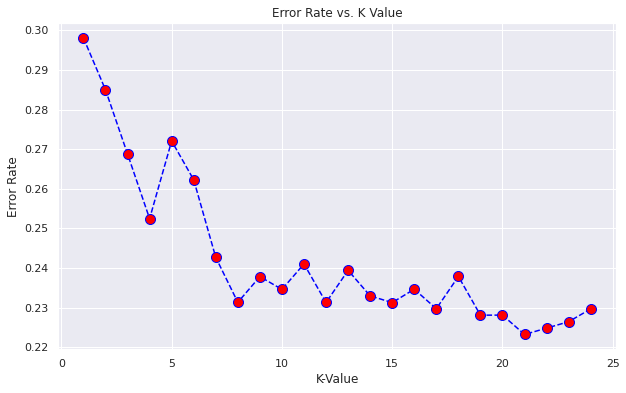

In [42]:
plt.figure(figsize=(10,6))
plt.plot(range(1,25),error_rate,color='blue', linestyle='dashed', marker='o',
       markerfacecolor='red', markersize=10)
#plt.plot(range(1,25),accuracy_rate,color='blue', linestyle='dashed', marker='o',
#         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K-Value')
plt.ylabel('Error Rate')

**In this kernel, we have performed Exploratory Data Analysis, Data Preprocessing, Visualization of Features, and KNN Model Building. Please give an upvote, if you like & find this kernel helpful. Thank You.** 